# CycleGAN Patchwise Inference
Dieses Notebook zeigt, wie ein trainierter CycleGAN-Generator große Bilder 
per Kachelgitter verarbeitet. Patches werden einzeln konvertiert und anschließend 
durch einfaches Mittelwerten wieder zusammengesetzt. Passe die Parameter unten 
(Checkpoint, Bildpfad, Patchgröße/Stride) an deinen Anwendungsfall an.

Standardmäßig nutzt das Notebook 256px-Patches (wie das aktuelle Training); passe TILE_SIZE/TILE_STRIDE unten an.

In [9]:

import math
from pathlib import Path

import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
from torchvision.transforms import functional as TF
from monai.inferers import SlidingWindowInferer

import os

os.chdir("/srv/store/docker-users/thesis/khajuria/day2night")
print("Current working directory:", os.getcwd())


from src.utils.common import load_cfg, resolve_encoder_checkpoint
from src.models.cyclegan import CycleGANGenerator
from src.apply_cyclegan import build_inference_transform


Current working directory: /srv/store/docker-users/thesis/khajuria/day2night


In [10]:

# --- Benutzer-Parameter ---
CONFIG_PATH = "experiments/cyclegan_day2night_20251125_233135/cyclegan.yaml"
CHECKPOINT_PATH = "experiments/cyclegan_day2night_20251125_233135/epoch_0200.pt" #None  # Optional: expliziter Pfad zu epoch_XXXX.pt
DIRECTION = "day2night"  # oder "night2day"
INPUT_IMAGE = "data/night2day/night_to_day/testA/1abbe94b-c840d3b2.jpg"
INPUT_RESIZE = None  # None = Originalgröße behalten, oder (Breite, Höhe)
ADAPTIVE_STRIDE = False  # False = fixes Kachelraster
TILE_SIZE = 512  # Patch-Größe (Training aktuell 256x256)
TILE_STRIDE = 512  # Standard: keine Überlappung
USE_MONAI = True  # True = SlidingWindowInferer verwenden
MONAI_SW_BATCH = 4
MONAI_OVERLAP = None  # None = automatisch aus Stride/Tile berechnen
SAVE_RESULT = True
OUTPUT_DIR = "results/cyclegan_patches"
OUTPUT_SUFFIX = "patched"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [11]:

def find_checkpoint(cfg, explicit=None):
    if explicit:
        path = Path(explicit)
        if not path.is_file():
            raise FileNotFoundError(f"Checkpoint nicht gefunden: {path}")
        return path
    exp_root = Path(cfg["logging"]["out_dir"])
    pattern = sorted(exp_root.glob(f"{cfg['exp_name']}_*/epoch_*.pt"))
    if not pattern:
        raise RuntimeError(f"Keine Checkpoints unter {exp_root} gefunden.")
    return pattern[-1]


def build_generator(cfg, device):
    gen_cfg = cfg["model"]["generator"]
    encoder_ckpt = resolve_encoder_checkpoint(
        gen_cfg.get("encoder_checkpoint"),
        experiments_root=cfg["logging"].get("out_dir", "experiments"),
        default_run_prefix=gen_cfg.get("encoder_run_prefix", "seg"),
        filename=gen_cfg.get("encoder_filename", "encoder_GE.pth"),
    )
    model = CycleGANGenerator(
        in_channels=gen_cfg.get("in_channels", 3),
        out_channels=gen_cfg.get("out_channels", 3),
        base_channels=gen_cfg.get("base_channels", 64),
        n_res_blocks=gen_cfg.get("n_res_blocks", 9),
        use_skip=gen_cfg.get("use_skip", True),
        encoder_checkpoint=encoder_ckpt,
        freeze_encoder=gen_cfg.get("freeze_encoder", False),
        decoder_res_blocks=gen_cfg.get("decoder_res_blocks", 3),
    ).to(device)
    return model


def prepare_image_tensor(pil_image, transform, tile_size, device, min_tiles_per_dim=2):
    tensor = transform(pil_image).unsqueeze(0).to(device)
    _, _, h, w = tensor.shape
    target_h = max(h, tile_size * min_tiles_per_dim)
    target_w = max(w, tile_size * min_tiles_per_dim)
    pad_h = max(0, target_h - h)
    pad_w = max(0, target_w - w)
    if pad_h > 0 or pad_w > 0:
        tensor = F.pad(tensor, (0, pad_w, 0, pad_h), mode="reflect")
    return tensor, h, w, target_h, target_w


def _make_coords(length, tile_size, stride):
    coords = list(range(0, max(length - tile_size, 0) + 1, stride))
    last = length - tile_size
    if coords[-1] != last:
        coords.append(last)
    return coords


def sliding_window_manual(generator, pil_image, transform, tile_size=256, stride=128, device=torch.device("cpu")):
    base, orig_h, orig_w, padded_h, padded_w = prepare_image_tensor(pil_image, transform, tile_size, device)
    base = base.squeeze(0)
    c, h, w = base.shape

    ys = _make_coords(h, tile_size, stride)
    xs = _make_coords(w, tile_size, stride)
    patch_count = len(ys) * len(xs)

    accum = torch.zeros((c, h, w), device=device)
    weight = torch.zeros((1, h, w), device=device)
    patch_weight = torch.ones((1, tile_size, tile_size), device=device)

    generator.eval()
    with torch.inference_mode():
        for y in ys:
            for x in xs:
                patch = base[:, y:y+tile_size, x:x+tile_size].unsqueeze(0)
                out = generator(patch)
                accum[:, y:y+tile_size, x:x+tile_size] += out.squeeze(0) * patch_weight
                weight[:, y:y+tile_size, x:x+tile_size] += patch_weight

    weight = weight.clamp_min(1e-6)
    result = accum / weight
    return result[:, :orig_h, :orig_w], patch_count


def sliding_window_monai(generator, pil_image, transform, tile_size=256, stride=128, device=torch.device("cpu"), sw_batch=4, overlap=None):
    tensor, orig_h, orig_w, padded_h, padded_w = prepare_image_tensor(pil_image, transform, tile_size, device)
    if overlap is None:
        overlap = 1.0 - min(1.0, stride / float(tile_size))
        overlap = max(0.0, min(0.9, overlap))
    inferer = SlidingWindowInferer(
        roi_size=(tile_size, tile_size),
        sw_batch_size=sw_batch,
        overlap=overlap,
        padding_mode="reflect",
        mode="gaussian",
    )
    generator.eval()
    with torch.inference_mode():
        output = inferer(tensor, generator)
    ys = _make_coords(padded_h, tile_size, stride)
    xs = _make_coords(padded_w, tile_size, stride)
    patch_count = len(ys) * len(xs)
    return output.squeeze(0)[:, :orig_h, :orig_w], patch_count


def tensor_to_image(tensor):
    tensor = tensor.detach().clamp(-1, 1)
    tensor = (tensor + 1) / 2
    return TF.to_pil_image(tensor.cpu())


In [12]:

cfg = load_cfg(CONFIG_PATH)

# Patch-Transform: keine Resize/Crop, nur Tensor + [-1,1]-Norm
patch_transform = lambda img: TF.normalize(TF.to_tensor(img), [0.5, 0.5, 0.5], [0.5, 0.5, 0.5])

tile_size = TILE_SIZE or 512
if not isinstance(tile_size, int):
    tile_size = int(tile_size)
tile_stride = TILE_STRIDE or tile_size

#TILE_SIZE = 256  # Patch-Größe (Training aktuell 256x256)
#TILE_STRIDE = 256  # Standard: keine Überlappung
print(f"Patch-Tiling: {TILE_SIZE}px Quadrate, stride={TILE_STRIDE}px (keine Resize/CenterCrop vorgelagert)")

checkpoint = find_checkpoint(cfg, CHECKPOINT_PATH)
print(f"Nutze Checkpoint: {checkpoint}")
key = "G" if DIRECTION == "day2night" else "F"
generator = build_generator(cfg, DEVICE)
generator.load_state_dict(torch.load(checkpoint, map_location="cpu", weights_only=True)[key])
generator.to(DEVICE)
generator.eval()
print(f"Generator für {DIRECTION} ist geladen und bereit.")


Patch-Tiling: 512px Quadrate, stride=512px (keine Resize/CenterCrop vorgelagert)
Nutze Checkpoint: experiments/cyclegan_day2night_20251125_233135/epoch_0200.pt
Generator für day2night ist geladen und bereit.


Tiling erzwingt mindestens 2x2 Patches (>=4 insgesamt), auch bei kleinen Bildern.
Verwendete Patches: 6
Gespeichert unter results/cyclegan_patches/day2night/1abbe94b-c840d3b2_patched.png


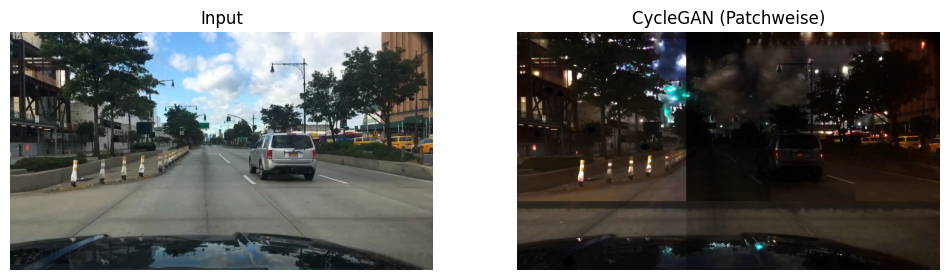

In [13]:

input_path = Path(INPUT_IMAGE)
if not input_path.is_file():
    raise FileNotFoundError(f"Eingangsbild nicht gefunden: {input_path}")
original = Image.open(input_path).convert("RGB")
processed_input = original
resize_note = None
if INPUT_RESIZE:
    if not isinstance(INPUT_RESIZE, (tuple, list)) or len(INPUT_RESIZE) != 2:
        raise ValueError("INPUT_RESIZE muss (Breite, Höhe) sein oder None")
    target_w, target_h = int(INPUT_RESIZE[0]), int(INPUT_RESIZE[1])
    if target_w <= 0 or target_h <= 0:
        raise ValueError("Breite/Höhe müssen positiv sein")
    processed_input = original.resize((target_w, target_h), Image.BICUBIC)
    resize_note = f"Input manuell auf {target_w}x{target_h} gesetzt."
if resize_note:
    print(resize_note + f" Original: {original.width}x{original.height}.")

print("Tiling erzwingt mindestens 2x2 Patches (>=4 insgesamt), auch bei kleinen Bildern.")

if USE_MONAI:
    output_tensor, patch_count = sliding_window_monai(
        generator,
        processed_input,
        patch_transform,
        tile_size=TILE_SIZE,
        stride=TILE_STRIDE,
        device=DEVICE,
        sw_batch=MONAI_SW_BATCH,
        overlap=MONAI_OVERLAP,
    )
else:
    output_tensor, patch_count = sliding_window_manual(
        generator,
        processed_input,
        patch_transform,
        tile_size=TILE_SIZE,
        stride=TILE_STRIDE,
        device=DEVICE,
    )

print(f"Verwendete Patches: {patch_count}")

result_img = tensor_to_image(output_tensor)

if SAVE_RESULT:
    out_dir = Path(OUTPUT_DIR) / DIRECTION
    out_dir.mkdir(parents=True, exist_ok=True)
    suffix = f"_{OUTPUT_SUFFIX}" if OUTPUT_SUFFIX else ""
    out_path = out_dir / f"{input_path.stem}{suffix}.png"
    result_img.save(out_path)
    print(f"Gespeichert unter {out_path}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(processed_input)
if resize_note:
    title = "Input (manuell resized)"
else:
    title = "Input"
plt.title(title)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(result_img)
plt.title("CycleGAN (Patchweise)")
plt.axis("off")
plt.show()
